# LBG ring-intercept: MCTS guard vs LQR bandit

End-to-end demo. 1 guard at ~200 m around the lady (RTN origin), 4
bandits on a 2:1 RT-plane natural-motion ring at ~2 km. HCW-RT
dynamics. Cold-gas thrusters: Moog 58E143 (3.6 N, GN2, Isp 65 s),
3 kg propellant.

CPU-only. See `running_on_mps.ipynb` for MPS install/setup and
`mcts_cpu_vs_mps.ipynb` for the batched-vs-sequential MCTS timing.

In [ ]:
# Pin CPU as default device before importing JAX. On Apple Silicon
# `jax-mps` may auto-register and become the default; the float64
# reference-orbit arrays would then hit MLX and error.
import os
os.environ['JAX_DEFAULT_DEVICE'] = 'cpu'

import sys
from pathlib import Path
_here = Path.cwd()
if (_here / 'src' / 'orbital_game').is_dir():
    _repo_root = _here
elif (_here.parent / 'src' / 'orbital_game').is_dir():
    _repo_root = _here.parent
else:
    raise RuntimeError(f'Could not locate orbital-game repo root from cwd={_here}')
if str(_repo_root) not in sys.path:
    sys.path.insert(0, str(_repo_root))

%load_ext autoreload
%autoreload 2

import time
from dataclasses import dataclass

import jax
import jax.numpy as jnp
import numpy as np
import matplotlib.pyplot as plt
from astrojax import Epoch

from orbital_game import OrbitalGameEnv, Side
from orbital_game.adapters.pomdp import POMDPAdapter
from orbital_game.config import ScenarioConfig, VehicleParamsSpec
from orbital_game.games.lady_bandit_guard import LadyBanditGuard
from orbital_game.policies.mcts import MCTSPolicy
from orbital_game.policies.uniform_random import UniformRandomDiscretePolicy
from orbital_game.reference_orbit import ReferenceOrbitState
from orbital_game.registry import DynamicsKey, StateComponentKey
from orbital_game.rewards.lbg_zero_sum import LbgZeroSumReward
from orbital_game.sampling.mass import ConstantMass
from orbital_game.sampling.side import RelativeEllipse
from orbital_game.sampling.spec import ICSpec
from orbital_game.termination.lbg_events import LbgEventTermination

# The bandit's controller — closed-form receding-horizon LQR. Lives in
# examples/policies because it's a controller choice, not part of the
# game definition (which we build inline below).
from examples.policies.lqr_bandit import LQRBanditPolicy


## 1. Problem definition

This is an asymmetric pursuit-evasion game in low-Earth orbit, played
in the Hill / RTN frame relative to a reference orbit:

- **Lady** — virtual asset at the RTN origin (the reference orbit
  itself). Has no agent; it just sits there.
- **Bandits** — adversarial spacecraft trying to reach the lady (within
  `breach_radius_m`).
- **Guard** — defending spacecraft trying to either intercept a bandit
  (within `catch_radius_m`) or buy enough time for the episode horizon
  to expire.

Bandits start on a 2:1 RT-plane natural-motion ellipse (the
"bandit ring") at uniformly-spaced phases — same orbit period as the
lady, drifting around her without any propulsion. The guard starts on
its own smaller ring at radius `guard_ring_radius_m`.

Dynamics are HCW-RT (Clohessy–Wiltshire, in-plane only — 4-D state per
vehicle: `[r, t, ṙ, ṫ]`), driven by impulsive Δv from cold-gas thrusters.
Reward is zero-sum: the guard's reward equals minus the bandit's, with a
dense distance-shaping term plus a large terminal payoff at catch / breach.

### 1.1 Vehicle parameters — cold-gas thrusters

Both sides fly identical small inspectors with a Moog 58E143-style
3.6 N GN₂ cold-gas thruster (Isp ≈ 65 s). 12 kg dry + 3 kg propellant
gives a wet mass of 15 kg and a total Δv budget of

$$\Delta v_\text{tot} \;=\; I_\text{sp} \, g_0 \, \ln\!\left(\frac{m_\text{wet}}{m_\text{dry}}\right) \;\approx\; 65 \cdot 9.81 \cdot \ln(15/12) \;\approx\; 142 \;\text{m/s}.$$

`VehicleParamsSpec` is the env-facing dataclass that the dynamics and
the `Mass` state component read from. It does NOT carry initial
propellant — that's a separate IC-sampler concern (`ConstantMass` below).

In [2]:
# Cold-gas thruster preset. Both sides identical; the env's `_FleetParams`
# pytree carries dry_mass / Isp / max_thrust as JAX scalars per side, so
# the dynamics step can vmap impulsive Δv with rocket-equation mass loss.
COLD_GAS_GUARD = VehicleParamsSpec(
    dry_mass_kg=12.0,
    isp_s=65.0,
    max_thrust_n=3.6,
)
COLD_GAS_BANDIT = VehicleParamsSpec(
    dry_mass_kg=12.0,
    isp_s=65.0,
    max_thrust_n=3.6,
)
PROPELLANT_KG = 3.0  # initial GN₂ load — sampled into state via ConstantMass below


### 1.2 Geometry, ICs, and the `ScenarioConfig`

Three layered objects produce the runnable env:

1. **`RingInterceptParams`** — knobs the user might tweak per
   experiment (ring radius, breach/catch distances, time step, seed).
2. **`ICSpec`** — how to sample the *initial state* of every guard and
   bandit at episode reset. We use `RelativeEllipse` on each side, which
   places vehicles on a 2:1 RT-plane natural-motion ellipse at the
   given phases (and `ConstantMass` to set initial propellant).
3. **`ScenarioConfig`** — the full env description: dynamics choice,
   per-side state components (`RT` + `MASS`), reward, termination, IC
   sampler, dt, max horizon. Once frozen, it builds the assembled
   per-side `GuardState` / `BanditState` pytree classes via
   `cfg.layout` so the `OrbitalGameEnv` can vmap over them.

In [ ]:
@dataclass(frozen=True)
class RingInterceptParams:
    """Tunable physical parameters for the LBG ring-intercept scenario.

    Each field is a physical quantity (m, s). `build_scenario` converts
    them into the framework objects (`ICSpec`, `ScenarioConfig`, ...).
    """
    # Number of bandit attackers. With n_bandits=1 the geometry is a
    # clean 1v1; with >1 the guard reward is the sum over bandits, so
    # the guard implicitly has to triage threats.
    n_bandits: int = 1
    # Bandit's radial-ellipse semi-major axis (m). Under HCW 2:1
    # bounded-orbit motion the along-track extent is 2× this, so 2000
    # m radial gives a 2 km × 4 km drift ellipse with no thrusting.
    ring_radius_m: float = 2000.0
    # Where on the guard's ring it starts. 0.0 puts it on the +R side.
    guard_phase_offset_rad: float = 0.0
    # Guard's defensive ring radius (m). Small enough to stay near the
    # lady, large enough that the guard has room to maneuver.
    guard_ring_radius_m: float = 200.0
    # Bandit wins if any bandit gets within this many meters of the lady.
    breach_radius_m: float = 5.0
    # Guard wins if any guard gets within this many meters of any bandit.
    # 10× larger than breach_radius_m so the game stays competitive
    # under a finite Δv budget.
    catch_radius_m: float = 50.0
    # Simulation step (seconds). One impulsive Δv per step. 10 s is
    # short relative to the ~95 min orbit so HCW integrates accurately.
    dt: float = 10.0
    # Episode horizon (seconds). If neither catch nor breach occurs by
    # then, the episode ends with whatever dense reward has accumulated.
    max_horizon_s: float = 2000.0
    # Top-level RNG seed. Threaded into IC sampling and per-step keys.
    seed: int = 0


# Episode start date as a calendar date — converted to MJD via astrojax
# below. Set wherever you want the simulation epoch to be; HCW dynamics
# don't actually use the epoch, but J2 / Keplerian dynamics would.
EPOCH = Epoch(2023, 5, 3)


def build_scenario(params: RingInterceptParams) -> ScenarioConfig:
    """Assemble the full ScenarioConfig.

    Flow:
        params  ─►  reference_orbit + IC sampler  ─►  ScenarioConfig
    plus a post-construction reward / termination override so the
    breach / catch radii match `params` exactly.
    """
    n_b = params.n_bandits

    # ----- Reference orbit ----------------------------------------------------
    # The lady sits at the RTN origin, but RTN is attached to a real
    # ECI orbit. ECI position + velocity define it; everything else
    # (mean motion, RAAN, argp) is derived. ~7000 km LEO, ~95 min period.
    reference_orbit = ReferenceOrbitState(
        position_eci=jnp.array([7000e3, 0.0, 0.0]),    # 7000 km radial [m]
        velocity_eci=jnp.array([0.0,    7.5e3, 0.0]),  # 7.5 km/s tangential [m/s]
    )

    # ----- IC sampler ---------------------------------------------------------
    # Bandit phases evenly spaced around the ring. endpoint=False
    # avoids a duplicate at 2π. With n_b=1 this is just [0.0].
    bandit_phases = jnp.linspace(0.0, 2.0 * jnp.pi, n_b, endpoint=False)

    # ICSpec bundles a per-side IC sampler with optional cross-side
    # validators. env.reset(key) calls each sampler, then runs the
    # validators; if they reject, it resamples up to max_attempts.
    ic_sampler = ICSpec(
        # RelativeEllipse produces ICs on a closed HCW relative orbit
        # (no secular drift). Each side gets its own ring geometry.
        guard_sampler=RelativeEllipse(
            radial_ellipse_m=params.guard_ring_radius_m,  # half-extent in R; T-extent is 2× this
            cross_track_m=0.0,                            # 0 means in-plane only (no N component)
            along_track_offset_m=0.0,                     # constant T shift of the ring center
            phase_rad=jnp.asarray([params.guard_phase_offset_rad]),  # shape (n_guards,)
            # Initial propellant for every guard. The Mass component on
            # the state pytree evolves it via the rocket equation.
            mass_sampler=ConstantMass(propellant_mass_kg=PROPELLANT_KG),
        ),
        bandit_sampler=RelativeEllipse(
            radial_ellipse_m=params.ring_radius_m,
            cross_track_m=0.0,
            along_track_offset_m=0.0,
            phase_rad=bandit_phases,                      # shape (n_bandits,)
            mass_sampler=ConstantMass(propellant_mass_kg=PROPELLANT_KG),
        ),
        # Cross-side validators run after sampling, e.g. "guards must
        # start ≥ X m from any bandit". Empty here means accept the
        # first draw.
        validators=(),
        # Resample budget if any validator rejects. Only matters when
        # validators is non-empty.
        max_attempts=10,
    )

    # ----- ScenarioConfig -----------------------------------------------------
    # Frozen dataclass that fully describes the env. OrbitalGameEnv(cfg)
    # reads it once and builds the per-side state classes + dynamics.
    cfg = ScenarioConfig(
        n_guards=1,
        n_bandits=n_b,
        # Calendar epoch of t=0 as Modified Julian Date. Needed by
        # J2 / Keplerian dynamics for frame conversion; HCW ignores it
        # but the field is required. EPOCH defined above as a calendar
        # date for readability.
        epoch_mjd_utc=float(EPOCH.mjd()),
        reference_orbit=reference_orbit,
        # Per-side state pytree composition. RT contributes the 4-D
        # in-plane state (R, T, Ṙ, Ṫ); MASS contributes the scalar
        # propellant tracker. Add RTN for full 6-D state, POWER for
        # battery state-of-charge, etc.
        guard_components=(StateComponentKey.RT, StateComponentKey.MASS),
        bandit_components=(StateComponentKey.RT, StateComponentKey.MASS),
        # Per-side propulsion / mass parameters. Used by the dynamics
        # step to convert thrust to Δv and update propellant mass.
        guard_params=COLD_GAS_GUARD,
        bandit_params=COLD_GAS_BANDIT,
        ic_sampler=ic_sampler,
        # Discretization and horizon. cfg.max_steps is computed as
        # int(max_horizon_s / dt).
        dt=params.dt,
        max_horizon_s=params.max_horizon_s,
        seed=params.seed,
        # truth_dynamics is what env.step actually integrates and
        # determines the truth-state frame. policy_dynamics is what
        # planners use to predict forward; matching it to truth makes
        # MCTS's tree search self-consistent with the real env.
        truth_dynamics=DynamicsKey.HCW_RT,
        policy_dynamics=DynamicsKey.HCW_RT,
        # Game metadata. LadyBanditGuard exposes breach_distance_m as
        # the single source of truth for the breach threshold;
        # termination and any breach-aware reward / obs read it from
        # cfg.game.
        game=LadyBanditGuard(breach_distance_m=params.breach_radius_m),
    )

    # ----- Reward + termination overrides -------------------------------------
    # ScenarioConfig.__post_init__ populates a default reward and
    # termination from `game`, but those defaults only see
    # game.breach_distance_m — the catch radius is unreachable. Replace
    # both with explicit instances so params.catch_radius_m takes effect.
    # object.__setattr__ is needed because the dataclass is frozen.
    object.__setattr__(
        cfg, 'termination_fn',
        # Episode ends when: any bandit reaches breach_radius_m of the
        # lady (bandit wins), any guard reaches catch_radius_m of any
        # bandit (guard wins), or step >= max_steps.
        LbgEventTermination(
            max_steps=cfg.max_steps,
            breach_radius_m=params.breach_radius_m,
            catch_radius_m=params.catch_radius_m,
        ),
    )
    object.__setattr__(
        cfg, 'reward_fn',
        # Zero-sum: dense distance shaping each step plus a large
        # terminal payoff (±1000) at catch / breach. Guard reward is
        # the negative of bandit reward.
        LbgZeroSumReward(
            catch_radius_m=params.catch_radius_m,
            breach_radius_m=params.breach_radius_m,
        ),
    )
    return cfg


params = RingInterceptParams(n_bandits=1)
cfg = build_scenario(params)
print(f'ScenarioConfig: n_guards={cfg.n_guards}, n_bandits={cfg.n_bandits}, '
      f'dt={cfg.dt}s, horizon={cfg.max_horizon_s}s')
print(f'epoch           = 2023-05-03  (MJD {cfg.epoch_mjd_utc})')
print(f'reward_fn       = {type(cfg.reward_fn).__name__}')
print(f'termination_fn  = {type(cfg.termination_fn).__name__}')
print(f'truth dynamics  = {cfg.truth_dynamics}')


## 2. Build the environment

`OrbitalGameEnv(cfg)` instantiates the symmetric multi-agent core: it
resolves dynamics callables, builds the per-side `GuardState` /
`BanditState` pytree classes from the configured components, and wires
the reward / termination / IC sampler.

`POMDPAdapter(env)` exposes a flat-state view of the env to planners
that need a single-vector state — like the MCTS guard below. The flat
state is *not* the same as the per-side observation: it concatenates
**both** sides' actor pytrees into one vector, then appends `(t, step)`
so that a time-dependent termination function (max-horizon expiry)
becomes Markov in the planner's state. That's why
`adapter.states_dim == cfg.layout.flat_dim + 2`.

In [4]:
env = OrbitalGameEnv(cfg)
adapter = POMDPAdapter(env)

print(f'mean motion = {env.mean_motion:.4e} rad/s   '
      f'(orbital period ~ {2*np.pi/env.mean_motion/60:.1f} min)')
print(f'guard cmd dv shape: {env.guard_command_cls.zeros(cfg.n_guards).dv.shape}   (RT: 2-D)')

# State-dim breakdown. Per-vehicle actor state = RT(4) + MASS(1) = 5.
# Flat actor state = 5 * (n_guards + n_bandits). The adapter appends
# (t, step) so a horizon-dependent termination function is Markov in the
# planner's state vector.
n_actor = cfg.layout.flat_dim
n_planner = adapter.states_dim
print(f'\nlayout.flat_dim     = {n_actor}   '
      f'(per-vehicle: RT(4)+MASS(1)=5; {cfg.n_guards}+{cfg.n_bandits} vehicles → 5*2={n_actor})')
print(f'adapter.states_dim  = {n_planner}   '
      f'(actor state {n_actor} + (t, step) tail = {n_actor}+2={n_planner})')

# Mass / Δv budget — derived from the cold-gas params + dt.
WET = COLD_GAS_GUARD.dry_mass_kg + PROPELLANT_KG
DV_MAX = COLD_GAS_GUARD.max_thrust_n * cfg.dt / WET
print(f'\nwet mass = {WET} kg')
print(f'max Δv per step (force * dt / wet mass) = {DV_MAX:.2f} m/s')
print(f'total Δv budget (Tsiolkovsky)            ~= '
      f'{COLD_GAS_BANDIT.isp_s * 9.80665 * np.log(WET / COLD_GAS_BANDIT.dry_mass_kg):.0f} m/s')


mean motion = 1.0977e-03 rad/s   (orbital period ~ 95.4 min)
guard cmd dv shape: (1, 2)   (RT: 2-D)

layout.flat_dim     = 10   (per-vehicle: RT(4)+MASS(1)=5; 1+1 vehicles → 5*2=10)
adapter.states_dim  = 12   (actor state 10 + (t, step) tail = 10+2=12)

wet mass = 15.0 kg
max Δv per step (force * dt / wet mass) = 2.40 m/s
total Δv budget (Tsiolkovsky)            ~= 142 m/s


## 3. Visualize initial conditions

Reset the env at a fixed seed and plot the resulting placement. The
`reset` returns `(state, initial_outputs)` where `initial_outputs` is
the per-side `BySide(SideOutput)` for `t=0` — we don't need them for the
geometry plot.

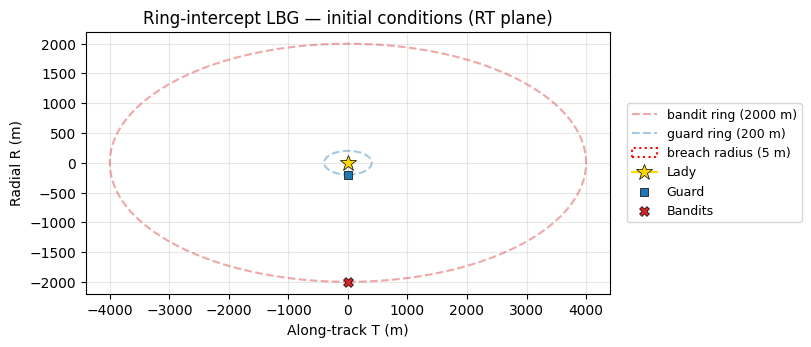

In [5]:
key0 = jax.random.PRNGKey(0)
state, _ = env.reset(key0)
gp = np.asarray(state.guards.rt[:, :2])
bp = np.asarray(state.bandits.rt[:, :2])

# Custom one-shot IC plot — there's no rollout yet, so this is just
# matplotlib. Markers are sized so the breach radius (5 m) is still
# readable next to the lady; the legend is anchored outside the axes
# to free up plotting area.
fig, ax = plt.subplots(figsize=(8, 5), constrained_layout=True)

theta = np.linspace(0, 2 * np.pi, 200)
r_e = params.ring_radius_m
ax.plot(2 * r_e * np.sin(theta), -r_e * np.cos(theta), 'C3--', alpha=0.4,
        label=f'bandit ring ({r_e:.0f} m)')
g_e = params.guard_ring_radius_m
ax.plot(2 * g_e * np.sin(theta), -g_e * np.cos(theta), 'C0--', alpha=0.4,
        label=f'guard ring ({g_e:.0f} m)')
br = params.breach_radius_m
ax.add_patch(plt.Circle((0, 0), br, fill=False, color='red', linestyle=':',
                        linewidth=1.5, label=f'breach radius ({br:.0f} m)'))

ax.plot(0, 0, marker='*', color='gold', markersize=12,
        markeredgecolor='black', markeredgewidth=0.5, label='Lady', zorder=5)
ax.scatter(gp[:, 1], gp[:, 0], s=40, c='C0', marker='s',
           edgecolors='black', linewidths=0.5, label='Guard', zorder=4)
ax.scatter(bp[:, 1], bp[:, 0], s=50, c='C3', marker='X',
           edgecolors='black', linewidths=0.5, label='Bandits', zorder=4)

ax.set_xlabel('Along-track T (m)')
ax.set_ylabel('Radial R (m)')
ax.set_title('Ring-intercept LBG — initial conditions (RT plane)')
ax.set_aspect('equal')
ax.grid(alpha=0.3)
ax.legend(loc='center left', bbox_to_anchor=(1.02, 0.5), fontsize=9, frameon=True)
plt.show()


## 4. Policies — MCTS guard vs LQR bandit

Both sides conform to a common `Policy` protocol:

```python
def __call__(policy_state, agent_view, key, t) -> (action, new_policy_state)
```

- `policy_state` carries any per-step memory (e.g. an EKF covariance, a
  recurrent hidden state). For *stateless* policies — random, MCTS,
  closed-form LQR — it's `None` going in and `None` coming out.
- `agent_view` is whatever the policy needs to act. **The MCTS guard
  expects the *flat packed env state*** (the one the adapter exposes)
  because its tree search needs to step the env model forward; reactive
  policies like the LQR bandit expect their own per-side flattened
  observation.
- `key` is a fresh PRNG split for stochastic action selection (Gumbel
  MuZero in the MCTS guard's case). `t` is current sim time.

`MCTSPolicy` takes an `opponent_model` — the searcher's belief about
how the *other* side will play, used to roll out child nodes. It's
distinct from the bandit's actual game-time policy, and a smarter
opponent model sharpens search at the cost of one extra Policy
evaluation per node. We start with uniform-random and revisit a
better choice in section 9.

In [6]:
# 9-direction RT-plane action grid (8 unit dirs at DV_MAX + no-op).
angles = np.linspace(0.0, 2.0 * np.pi, 8, endpoint=False)
grid_2d = DV_MAX * np.stack([np.cos(angles), np.sin(angles)], axis=-1)
action_grid = jnp.asarray(np.concatenate([grid_2d, np.zeros((1, 2))], axis=0), dtype=jnp.float32)
print('action grid shape:', action_grid.shape)

# Bandit-side LQR policy (closed-form, vmappable).
lqr = LQRBanditPolicy.from_env(env, horizon=8, control_cost=1e-3, dv_max=DV_MAX)
print(f'LQR bandit: gain shape={lqr.gain.shape}, dv_max={lqr.dv_max:.2f} m/s')

# MCTS guard. Default opponent model = uniform-random over the same grid.
opponent_model = UniformRandomDiscretePolicy(
    action_grid=action_grid,
    n_vehicles=cfg.n_bandits,
    command_cls=env.bandit_command_cls,
)
mcts = MCTSPolicy(
    env_model=adapter,
    side=Side.GUARD,
    action_grid=action_grid,
    opponent_model=opponent_model,
    opponent_action_grid=action_grid,
    num_simulations=32,
    n_vehicles=cfg.n_guards,
    command_cls=env.guard_command_cls,
)
print(f'MCTS guard: A={action_grid.shape[0]}, num_simulations={mcts.num_simulations}, '
      f'variant={mcts.variant}')


action grid shape: (9, 2)
LQR bandit: gain shape=(2, 4), dv_max=2.40 m/s
MCTS guard: A=9, num_simulations=32, variant=gumbel_muzero


## 5. Single trajectory — Python outer loop

The demo drives the env from a manual Python loop instead of
`orbital_game.rollout.rollout` because the two sides expect different
`agent_view` types: the MCTS guard wants the flat packed truth state,
while the LQR bandit wants its per-side flattened observation. The
built-in rollout passes the same shape to both sides, so we drive each
side explicitly here.

The loop below is heavily commented so each line's purpose is clear —
when you read it think *who needs what, and why*.

In [7]:
from orbital_game.env.types import Actions, BySide, SideTrajectory, Trajectory
from orbital_game.observations.types import flatten_observations


def _stack_pytrees(items):
    """jnp.stack along a new leading axis across a list of like-typed pytrees."""
    return jax.tree_util.tree_map(lambda *xs: jnp.stack(xs, axis=0), *items)


def run_one_trajectory(env, adapter, guard_policy, bandit_policy, key, max_steps):
    """Manual outer loop with per-side asymmetric agent views.

    Why not use ``orbital_game.rollout.rollout``? Because the two sides
    here expect *different* ``agent_view`` types: the MCTS guard wants
    the flat-packed truth state (so its tree search can step the env
    model forward without unpacking pytrees); the LQR bandit wants its
    per-side flattened observation. ``rollout()`` passes the same shape
    to both sides, so we drive each side explicitly.

    Returns ``(traj, final_state, n_real_steps)``. The Trajectory is
    padded to ``n_real_steps + 1`` frames so the final post-step state
    is included for viz; the trailing action is a no-op and trailing
    reward is 0 (same convention as freeze-on-done in ``rollout``).
    """
    # `env.reset` returns (state at t=0, per-side outputs at t=0).
    # The per-side outputs already contain the per-side observation —
    # we don't need to call the obs function manually. The bandit needs
    # its own flat per-side view to choose its first action.
    state, initial_outputs = env.reset(jax.random.fold_in(key, 0))
    bandit_view = flatten_observations(initial_outputs.bandit.obs)

    pre_states: list = []
    actions_g: list = []
    actions_b: list = []
    rewards_g: list = []
    rewards_b: list = []
    dones: list = []

    for step in range(max_steps):
        # One fresh PRNG split per role per step. Folding in `step + 1`
        # makes the per-step keys reproducible from the top-level seed.
        sub = jax.random.fold_in(key, step + 1)
        k_g, k_b, k_env = jax.random.split(sub, 3)

        # ---- MCTS guard --------------------------------------------------
        # `adapter.pack(state)` flattens (guards-pytree, bandits-pytree,
        # t, step) into a single 12-D float vector — the planner-Markov
        # state. MCTS's tree search expands children by stepping the env
        # MODEL forward, so it needs the full truth-state vector, not the
        # guard-side observation (which could be range-limited or noisy).
        s_flat = adapter.pack(state)
        # The Policy protocol is `policy(policy_state, agent_view, key, t)
        # → (action, new_policy_state)`. MCTS is stateless across calls
        # (it rebuilds the tree each time), so `policy_state` is `None`
        # going in and we discard the returned `_`. `key` is used for the
        # Gumbel-MuZero stochastic action sampling at the root.
        g_cmd, _ = guard_policy(None, s_flat, k_g, state.t)

        # ---- LQR bandit --------------------------------------------------
        # The bandit just needs its own per-side flattened observation
        # — that's what `env.reset` / `env.step` already produced. The
        # bandit policy's `__call__` ignores `key` (deterministic LQR)
        # and `t` (gain is time-invariant), but the protocol still
        # passes them.
        b_cmd, _ = bandit_policy(None, bandit_view, k_b, state.t)

        # ---- Step the env ------------------------------------------------
        # Both sides' actions go into the common `Actions` pytree.
        # `env.step` (1) propagates the dynamics, (2) computes per-side
        # rewards from (state_pre, actions, state_post), (3) regenerates
        # per-side observations at the post-step state, (4) latches
        # `episode_done` from the termination function.
        actions = Actions(sides=BySide(guard=g_cmd, bandit=b_cmd))
        out = env.step(k_env, state, actions)

        # Log everything for the Trajectory we'll build at the end.
        pre_states.append(state)
        actions_g.append(g_cmd)
        actions_b.append(b_cmd)
        rewards_g.append(out.outputs.guard.reward)
        rewards_b.append(out.outputs.bandit.reward)
        dones.append(out.episode_done)

        # Advance: post-step state is next iter's input; post-step
        # bandit obs is the bandit's view for picking the next action.
        state = out.state
        bandit_view = flatten_observations(out.outputs.bandit.obs)

        # Early-out on terminal events (catch / breach / horizon).
        if bool(out.episode_done):
            break

    n_real = len(pre_states)
    final_state = state

    # Pad to T+1 with a no-op action and zero terminal reward so the
    # final post-step state is included in the Trajectory for viz.
    g_zero = env.guard_command_cls.zeros(cfg.n_guards)
    b_zero = env.bandit_command_cls.zeros(cfg.n_bandits)
    all_states = pre_states + [final_state]
    all_actions_g = actions_g + [g_zero]
    all_actions_b = actions_b + [b_zero]
    all_rewards_g = rewards_g + [jnp.asarray(0.0)]
    all_rewards_b = rewards_b + [jnp.asarray(0.0)]
    all_dones = dones + [jnp.asarray(True)]

    traj = Trajectory(
        env_state=_stack_pytrees(all_states),
        sides=BySide(
            guard=SideTrajectory(
                obs=jnp.zeros((n_real + 1, 0)),
                action=_stack_pytrees(all_actions_g),
                reward=jnp.stack(all_rewards_g),
                done=jnp.stack(all_dones),
                policy_state=None,
            ),
            bandit=SideTrajectory(
                obs=jnp.zeros((n_real + 1, 0)),
                action=_stack_pytrees(all_actions_b),
                reward=jnp.stack(all_rewards_b),
                done=jnp.stack(all_dones),
                policy_state=None,
            ),
        ),
        episode_done=jnp.stack(all_dones),
        controlled_side=Side.GUARD,
    )
    return traj, final_state, n_real


t0 = time.perf_counter()
traj_demo, final_demo, n_steps = run_one_trajectory(
    env, adapter, mcts, lqr,
    key=jax.random.PRNGKey(7),
    max_steps=int(cfg.max_horizon_s / cfg.dt),
)
elapsed = time.perf_counter() - t0

rg = np.asarray(traj_demo.sides.guard.reward[:n_steps])
rb = np.asarray(traj_demo.sides.bandit.reward[:n_steps])
print(f'Trajectory: {n_steps} steps in {elapsed:.2f}s ({elapsed/max(1,n_steps)*1000:.1f} ms/step avg)')
print(f'Guard cum reward:  {rg.sum():.1f}')
print(f'Bandit cum reward: {rb.sum():.1f}')
print(f'Final propellant — guard:   {float(final_demo.guards.propellant_mass[0]):.3f} kg')
print(f'Final propellant — bandits: {np.asarray(final_demo.bandits.propellant_mass)} kg')


Trajectory: 26 steps in 26.32s (1012.3 ms/step avg)
Guard cum reward:  -1032.5
Bandit cum reward: 981.2
Final propellant — guard:   1.652 kg
Final propellant — bandits: [2.27043128] kg


## 6. Trajectory and reward plots

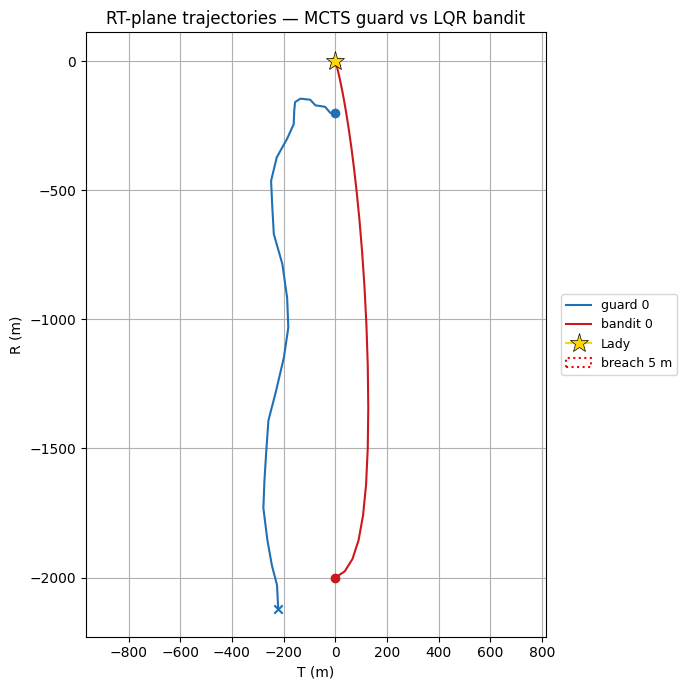

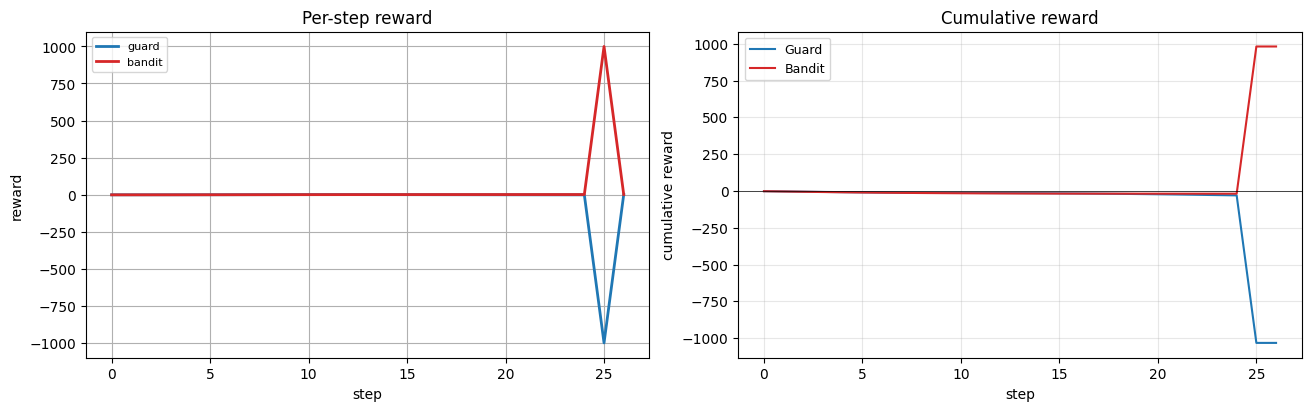

In [8]:
from orbital_game.viz import plot_rollout_panels, plot_rollout_rewards
from orbital_game.viz.summaries import plot_reward_curve

# Trajectory: use the package helper. For RT-only scenarios it lays out a
# single RT panel; ax is recovered from `fig.axes[0]` and decorated with
# scenario-specific overlays (Lady, breach radius). Side coloring (blues
# vs reds) and endpoint markers are handled inside plot_rollout_panels.
fig_traj = plot_rollout_panels(traj_demo, fig=plt.figure(figsize=(7, 7)))
ax_rt = fig_traj.axes[0]
ax_rt.plot(0, 0, marker='*', color='gold', markersize=14,
           markeredgecolor='black', markeredgewidth=0.5, label='Lady', zorder=5)
ax_rt.add_patch(plt.Circle((0, 0), params.breach_radius_m, fill=False,
                           color='red', linestyle=':', linewidth=1.5,
                           label=f'breach {params.breach_radius_m:.0f} m'))
ax_rt.set_title('RT-plane trajectories — MCTS guard vs LQR bandit')
# Replace the helper's inline legend with one anchored outside the axes
# so it doesn't sit on top of the trajectory.
existing = ax_rt.get_legend()
if existing is not None:
    existing.remove()
ax_rt.legend(loc='center left', bbox_to_anchor=(1.02, 0.5), fontsize=9, frameon=True)
fig_traj.tight_layout()
plt.show()

# Reward curves — per-step from plot_rollout_rewards, cumulative from
# plot_reward_curve(np.cumsum(...)). The cumulative plot is what makes
# the breach event visually obvious.
fig_rew, axes = plt.subplots(1, 2, figsize=(13, 4), constrained_layout=True)
plot_rollout_rewards(traj_demo, ax=axes[0])
axes[0].set_title('Per-step reward')

axes[1].plot(jnp.cumsum(traj_demo.sides.guard.reward), color='tab:blue', label='Guard')
axes[1].plot(jnp.cumsum(traj_demo.sides.bandit.reward), color='tab:red', label='Bandit')
axes[1].axhline(0, color='k', linewidth=0.5)
axes[1].set_xlabel('step')
axes[1].set_ylabel('cumulative reward')
axes[1].set_title('Cumulative reward')
axes[1].grid(True, alpha=0.3)
axes[1].legend(loc='best', fontsize=9)
plt.show()


## 7. Propellant mass

Both sides carry the `Mass` component (`StateComponentKey.MASS` in the
config), so propellant burn shows up directly in
`state.{guards,bandits}.propellant_mass`. `plot_rollout_mass` reads the
field for any side that has it and skips sides that don't.

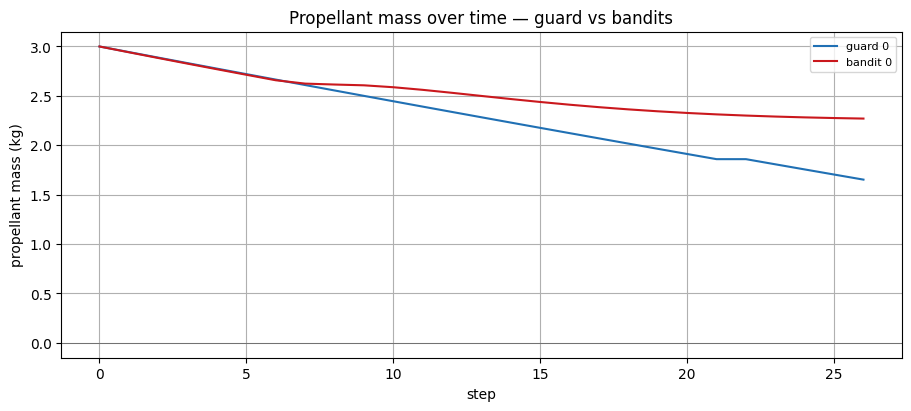

In [9]:
from orbital_game.viz import plot_rollout_mass

fig_mass, ax_mass = plt.subplots(figsize=(9, 4), constrained_layout=True)
plot_rollout_mass(traj_demo, ax=ax_mass)
ax_mass.set_title('Propellant mass over time — guard vs bandits')
ax_mass.axhline(0, color='k', linewidth=0.5, alpha=0.5)
plt.show()


## 8. Animation

`RolloutScene` bundles the trajectory + render configuration; `mode="auto"`
picks a 2D RT-plane animator because both sides only carry the 4-dim
`rt` state component (no `rtn`). `show_thrust=True` overlays Δv arrows at
each agent — they're scaled to `thrust_max_fraction` of the axis extent
so the largest maneuver is always visible.

`save_animation(scene, ...)` writes an MP4 via ffmpeg; the result is
rendered inline below via `IPython.display.Video` (with `embed=False` so
the video file lives in `outputs/` rather than bloating the notebook).

In [10]:
from pathlib import Path

from IPython.display import Video

from orbital_game.viz import RolloutScene, save_animation

scene = RolloutScene(
    traj=traj_demo,
    cfg=cfg,
    dt=cfg.dt,
    show_thrust=True,
    show_reference_marker=True,  # black star at origin = lady
    title_prefix='Ring intercept — ',
    figsize=(7.0, 7.0),
)
print(f'Animation: mode={scene.resolved_mode}, frames={scene.n_frames}, '
      f'axis_limit={scene.axis_limit_m:.0f} m')

out_dir = _repo_root / 'outputs'
out_dir.mkdir(exist_ok=True)
out_path = out_dir / 'lbg_ring_intercept.mp4'
save_animation(scene, str(out_path), fps=8, dpi=120)
print(f'Saved animation to {out_path}')
Video(str(out_path), embed=False)


Animation: mode=2d, frames=27, axis_limit=2335 m
Saved animation to /Users/duncan/repos/orbital-game/outputs/lbg_ring_intercept.mp4


## 9. Sharpening MCTS with a smarter opponent model

Inside the search, when the guard branches on its own action choices,
it must also predict the bandit's response to evaluate the resulting
state. That response is generated by `opponent_model` — *not* the
bandit's actual game-time policy. The two are deliberately separate:

- **`bandit_policy` (game-time)** — what the bandit actually does each
  tick when we step the env. We use `LQRBanditPolicy` here.
- **`opponent_model` (search-time)** — what the MCTS guard *believes*
  the bandit will do at each simulated child node. With
  `UniformRandomDiscretePolicy` (the default) the guard assumes the
  bandit picks moves uniformly — a deliberately pessimistic guess that
  makes the search look broad but unfocused.

A more accurate `opponent_model` lets the guard prune branches it can
already predict the bandit will lose, and concentrate simulations on
the genuinely contested branches. Below we rebuild the MCTS guard
using the same `LQRBanditPolicy` that the bandit will play with at
game-time — a strong-but-imperfect model of the actual opponent.

> Cost: one extra `Policy` evaluation per simulated step. For LQR
> (just two matmuls + a clip) this is essentially free; for a learned
> policy it would be the dominant cost.

In [11]:
# Same MCTS configuration as before, except `opponent_model` is now an
# LQR controller — the searcher's belief about the bandit is closer to
# what the bandit will actually do at game time.
mcts_lqr_opp = MCTSPolicy(
    env_model=adapter,
    side=Side.GUARD,
    action_grid=action_grid,
    opponent_model=lqr,
    opponent_action_grid=action_grid,
    num_simulations=mcts.num_simulations,
    n_vehicles=cfg.n_guards,
    command_cls=env.guard_command_cls,
)
print(f'MCTS guard (LQR opponent model): A={action_grid.shape[0]}, '
      f'num_simulations={mcts_lqr_opp.num_simulations}')

# We pick a seed where the two opponent-model variants diverge clearly:
# at seed=13, uniform-opp MCTS misses the catch and gives up a breach,
# while LQR-opp MCTS intercepts the bandit early. Single seeds are
# noisy — this is a *demonstration* of why opponent-model choice
# matters; the population-level comparison is in section 10.
DEMO_SEED = 13
COMPARE_KEY = jax.random.PRNGKey(DEMO_SEED)
demo_max_steps = int(cfg.max_horizon_s / cfg.dt)

# Re-run uniform-opp MCTS at the demo seed so the comparison is paired
# (same IC, same per-step env keys for both variants).
t0 = time.perf_counter()
traj_unif_demo, final_unif_demo, n_unif_demo = run_one_trajectory(
    env, adapter, mcts, lqr, key=COMPARE_KEY, max_steps=demo_max_steps,
)
elapsed_unif = time.perf_counter() - t0

t0 = time.perf_counter()
traj_lqr_opp, final_lqr_opp, n_lqr_opp = run_one_trajectory(
    env, adapter, mcts_lqr_opp, lqr, key=COMPARE_KEY, max_steps=demo_max_steps,
)
elapsed_lqr = time.perf_counter() - t0

rg_unif = np.asarray(traj_unif_demo.sides.guard.reward[:n_unif_demo])
rg_lqr  = np.asarray(traj_lqr_opp.sides.guard.reward[:n_lqr_opp])
prop_unif = float(final_unif_demo.guards.propellant_mass[0])
prop_lqr  = float(final_lqr_opp.guards.propellant_mass[0])

print(f'\n=== Uniform-opponent MCTS, seed={DEMO_SEED} ===')
print(f'  steps={n_unif_demo}, time={elapsed_unif:.2f}s   '
      f'guard cum reward {rg_unif.sum():+8.1f}   propellant {prop_unif:.2f} kg')

print(f'\n=== LQR-opponent MCTS, seed={DEMO_SEED} ===')
print(f'  steps={n_lqr_opp}, time={elapsed_lqr:.2f}s   '
      f'guard cum reward {rg_lqr.sum():+8.1f}   propellant {prop_lqr:.2f} kg')

print(f'\nΔ guard reward (LQR-opp − uniform-opp): {rg_lqr.sum() - rg_unif.sum():+.1f}')


MCTS guard (LQR opponent model): A=9, num_simulations=32

=== Uniform-opponent MCTS, seed=13 ===
  steps=26, time=20.63s   guard cum reward  -1029.6   propellant 1.76 kg

=== LQR-opponent MCTS, seed=13 ===
  steps=11, time=7.30s   guard cum reward   +988.7   propellant 2.50 kg

Δ guard reward (LQR-opp − uniform-opp): +2018.3


In [ ]:
# Side-by-side: same RT-plane trajectory plot for both MCTS variants
# (paired at the demo seed defined above).
#
# Compute SHARED axis limits over both trajectories so the panels are
# directly comparable. Without this, set_aspect('equal') + per-panel
# autoscale would squash the LQR-opp panel into a narrow strip because
# its trajectory ends earlier (catch in 11 steps).
def _xy_extent(traj):
    g = np.asarray(traj.env_state.guards.rt[..., :2])  # cols [R, T]
    b = np.asarray(traj.env_state.bandits.rt[..., :2])
    pts = np.concatenate([g.reshape(-1, 2), b.reshape(-1, 2)], axis=0)
    return pts[:, 1], pts[:, 0]  # plot-x = T, plot-y = R

xs_u, ys_u = _xy_extent(traj_unif_demo)
xs_l, ys_l = _xy_extent(traj_lqr_opp)
all_x = np.concatenate([xs_u, xs_l, [0.0]])  # include lady at origin
all_y = np.concatenate([ys_u, ys_l, [0.0]])
pad_x = 0.10 * (all_x.max() - all_x.min())
pad_y = 0.05 * (all_y.max() - all_y.min())
xlim = (all_x.min() - pad_x, all_x.max() + pad_x)
ylim = (all_y.min() - pad_y, all_y.max() + pad_y)

fig, axes = plt.subplots(1, 2, figsize=(14, 7.5), constrained_layout=True)

for ax, traj, title in (
    (axes[0], traj_unif_demo, f'MCTS — uniform opponent  (seed={DEMO_SEED})'),
    (axes[1], traj_lqr_opp,   f'MCTS — LQR opponent      (seed={DEMO_SEED})'),
):
    g_xyz = np.asarray(traj.env_state.guards.rt[..., :2])
    b_xyz = np.asarray(traj.env_state.bandits.rt[..., :2])
    for i in range(g_xyz.shape[1]):
        ax.plot(g_xyz[:, i, 1], g_xyz[:, i, 0], color='tab:blue', linewidth=1.5,
                label=f'guard {i}' if i == 0 else None)
        ax.scatter(g_xyz[0, i, 1], g_xyz[0, i, 0], marker='o', color='tab:blue', s=30, zorder=3)
        ax.scatter(g_xyz[-1, i, 1], g_xyz[-1, i, 0], marker='x', color='tab:blue', s=40, zorder=3)
    for j in range(b_xyz.shape[1]):
        ax.plot(b_xyz[:, j, 1], b_xyz[:, j, 0], color='tab:red', linewidth=1.5,
                label=f'bandit {j}' if j == 0 else None)
        ax.scatter(b_xyz[0, j, 1], b_xyz[0, j, 0], marker='o', color='tab:red', s=30, zorder=3)
        ax.scatter(b_xyz[-1, j, 1], b_xyz[-1, j, 0], marker='x', color='tab:red', s=40, zorder=3)
    ax.plot(0, 0, marker='*', color='gold', markersize=14,
            markeredgecolor='black', markeredgewidth=0.5, label='Lady', zorder=5)
    ax.add_patch(plt.Circle((0, 0), params.breach_radius_m, fill=False,
                            color='red', linestyle=':', linewidth=1.5))
    ax.set_xlabel('Along-track T (m)')
    ax.set_ylabel('Radial R (m)')
    ax.set_xlim(*xlim)
    ax.set_ylim(*ylim)
    ax.set_aspect('equal')
    ax.grid(alpha=0.3)
    ax.set_title(title)
    ax.legend(loc='upper right', fontsize=9, framealpha=0.9)
plt.show()

# Cumulative-reward comparison for the two opponent-model variants.
fig, ax = plt.subplots(figsize=(9, 4), constrained_layout=True)
ax.plot(jnp.cumsum(traj_unif_demo.sides.guard.reward), color='tab:blue',
        linestyle='--', label='Guard, uniform opp')
ax.plot(jnp.cumsum(traj_lqr_opp.sides.guard.reward), color='tab:blue',
        linestyle='-', label='Guard, LQR opp')
ax.plot(jnp.cumsum(traj_unif_demo.sides.bandit.reward), color='tab:red',
        linestyle='--', label='Bandit, uniform opp')
ax.plot(jnp.cumsum(traj_lqr_opp.sides.bandit.reward), color='tab:red',
        linestyle='-', label='Bandit, LQR opp')
ax.axhline(0, color='k', linewidth=0.5)
ax.set_xlabel('step')
ax.set_ylabel('cumulative reward')
ax.set_title(f'Cumulative reward — uniform vs LQR opponent model  (seed={DEMO_SEED})')
ax.grid(alpha=0.3)
ax.legend(loc='best', fontsize=9)
plt.show()


In [ ]:
# Propellant-burn comparison for the two opponent-model variants. The
# LQR-opp guard is more decisive — burns harder per step but for fewer
# steps because it intercepts early. The uniform-opp guard burns more
# slowly but for the full episode and still gives up the breach.
fig, axes = plt.subplots(1, 2, figsize=(14, 4), constrained_layout=True, sharey=True)

for ax, traj, title in (
    (axes[0], traj_unif_demo, f'Uniform opponent  (seed={DEMO_SEED})'),
    (axes[1], traj_lqr_opp,   f'LQR opponent      (seed={DEMO_SEED})'),
):
    plot_rollout_mass(traj, ax=ax)
    ax.set_title(title)
    ax.axhline(0, color='k', linewidth=0.5, alpha=0.5)
    ax.set_ylim(bottom=0)

# Overlay all four mass curves on a single axes for a tighter comparison.
fig, ax = plt.subplots(figsize=(9, 4), constrained_layout=True)
ax.plot(np.asarray(traj_unif_demo.env_state.guards.propellant_mass[:, 0]),
        color='tab:blue', linestyle='--', label='Guard, uniform opp')
ax.plot(np.asarray(traj_lqr_opp.env_state.guards.propellant_mass[:, 0]),
        color='tab:blue', linestyle='-',  label='Guard, LQR opp')
ax.plot(np.asarray(traj_unif_demo.env_state.bandits.propellant_mass[:, 0]),
        color='tab:red', linestyle='--', label='Bandit, uniform opp')
ax.plot(np.asarray(traj_lqr_opp.env_state.bandits.propellant_mass[:, 0]),
        color='tab:red', linestyle='-',  label='Bandit, LQR opp')
ax.set_xlabel('step')
ax.set_ylabel('propellant mass (kg)')
ax.set_title(f'Propellant mass over time — uniform vs LQR opponent  (seed={DEMO_SEED})')
ax.set_ylim(bottom=0)
ax.grid(alpha=0.3)
ax.legend(loc='best', fontsize=9)
plt.show()

print(f'Guard propellant used (uniform opp): '
      f'{PROPELLANT_KG - prop_unif:.3f} kg over {n_unif_demo} steps  '
      f'({(PROPELLANT_KG - prop_unif) / max(1, n_unif_demo):.4f} kg/step)')
print(f'Guard propellant used (LQR opp):     '
      f'{PROPELLANT_KG - prop_lqr:.3f} kg over {n_lqr_opp} steps  '
      f'({(PROPELLANT_KG - prop_lqr) / max(1, n_lqr_opp):.4f} kg/step)')


In [ ]:
# Animation of the LQR-opponent run — same RolloutScene wiring as
# section 8, just pointed at `traj_lqr_opp`. The catch event terminates
# the rollout early, so the video is shorter than the uniform-opp one.
scene_lqr = RolloutScene(
    traj=traj_lqr_opp,
    cfg=cfg,
    dt=cfg.dt,
    show_thrust=True,
    show_reference_marker=True,
    title_prefix=f'Ring intercept (LQR opp, seed={DEMO_SEED}) — ',
    figsize=(7.0, 7.0),
)
print(f'Animation: mode={scene_lqr.resolved_mode}, frames={scene_lqr.n_frames}, '
      f'axis_limit={scene_lqr.axis_limit_m:.0f} m')

out_path_lqr = out_dir / 'lbg_ring_intercept_lqr_opp.mp4'
save_animation(scene_lqr, str(out_path_lqr), fps=8, dpi=120)
print(f'Saved animation to {out_path_lqr}')
Video(str(out_path_lqr), embed=False)


## 10. Multi-trajectory comparison

Single trajectories are noisy — the per-step PRNG keys make MCTS
stochastic, so a comparison at one seed can flip on the wrong tick. To
measure relative strength we run each configuration over `N_TRAJ`
independent seeds (each seed shares its IC across configurations, so
the comparison is paired) and aggregate:

| config              | guard policy | bandit policy | search-time opponent model |
|---------------------|--------------|---------------|----------------------------|
| Random              | uniform      | LQR           | n/a                        |
| MCTS, uniform opp   | MCTS         | LQR           | uniform                    |
| MCTS, LQR opp       | MCTS         | LQR           | LQR                        |

Three plots are produced: bar chart of mean cumulative guard reward,
stacked breach / catch / neither counts, and per-config propellant
spend distribution.

In [13]:
def evaluate(env, adapter, guard_policy, bandit_policy, n_traj, max_steps, base_seed=42):
    """Run `n_traj` rollouts; return per-trajectory guard reward, propellant
    used by the guard, and breach/catch outcome counts."""
    rewards = []
    propellant_used = []
    breaches = catches = 0
    for j in range(n_traj):
        traj, final_state, n_real = run_one_trajectory(
            env, adapter, guard_policy, bandit_policy,
            key=jax.random.PRNGKey(base_seed + j),
            max_steps=max_steps,
        )
        rg = np.asarray(traj.sides.guard.reward[:n_real])
        rewards.append(rg.sum())

        # Propellant used = initial - final (per guard, summed if > 1).
        prop_init = float(np.sum(traj.env_state.guards.propellant_mass[0]))
        prop_final = float(np.sum(final_state.guards.propellant_mass))
        propellant_used.append(prop_init - prop_final)

        last_b = np.asarray(final_state.bandits.rt[:, :2])
        last_g = np.asarray(final_state.guards.rt[:, :2])
        d_lady = np.linalg.norm(last_b, axis=-1).min()
        d_gb = np.linalg.norm(last_g[:, None] - last_b, axis=-1).min()
        if d_lady < cfg.game.breach_distance_m:
            breaches += 1
        if d_gb < params.catch_radius_m:
            catches += 1
    return np.array(rewards), np.array(propellant_used), breaches, catches


N_TRAJ = 8
SHORT_MAX_STEPS = 60

guard_random = UniformRandomDiscretePolicy(
    action_grid=action_grid, n_vehicles=cfg.n_guards, command_cls=env.guard_command_cls,
)

configs = [
    ('Random',            guard_random,  '#888888'),
    ('MCTS\n(uniform opp)', mcts,        'tab:blue'),
    ('MCTS\n(LQR opp)',    mcts_lqr_opp, 'tab:cyan'),
]

results = {}  # name -> (rewards, propellant_used, breaches, catches)
for name, gp, _color in configs:
    label = name.replace('\n', ' ')
    print(f'\n=== {label}  ({N_TRAJ} trajectories) ===')
    r, p, br, ca = evaluate(env, adapter, gp, lqr, N_TRAJ, SHORT_MAX_STEPS)
    results[name] = (r, p, br, ca)
    print(f'  Outcomes: {br} breaches, {ca} catches | '
          f'mean reward {r.mean():+.1f} ± {r.std():.1f} | '
          f'mean propellant used {p.mean():.2f} kg')

# Headline numbers vs random baseline.
r_rand = results['Random'][0]
for name, (r, _p, _br, _ca) in results.items():
    if name == 'Random':
        continue
    label = name.replace('\n', ' ')
    print(f"\n{label} reward improvement over Random: {r.mean() - r_rand.mean():+.1f}")



=== Random  (8 trajectories) ===
  Outcomes: 7 breaches, 1 catches | mean reward -775.4 ± 666.6 | mean propellant used 1.19 kg

=== MCTS (uniform opp)  (8 trajectories) ===
  Outcomes: 6 breaches, 2 catches | mean reward -525.6 ± 871.3 | mean propellant used 1.26 kg

=== MCTS (LQR opp)  (8 trajectories) ===
  Outcomes: 5 breaches, 3 catches | mean reward -270.5 ± 975.0 | mean propellant used 1.03 kg

MCTS (uniform opp) reward improvement over Random: +249.8

MCTS (LQR opp) reward improvement over Random: +504.8


/var/folders/66/25bqc2bn19bb84ddx70zwv9m0000gn/T/ipykernel_45076/396102032.py:38: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = ax.boxplot(prop_arrays, labels=names, patch_artist=True, widths=0.6,


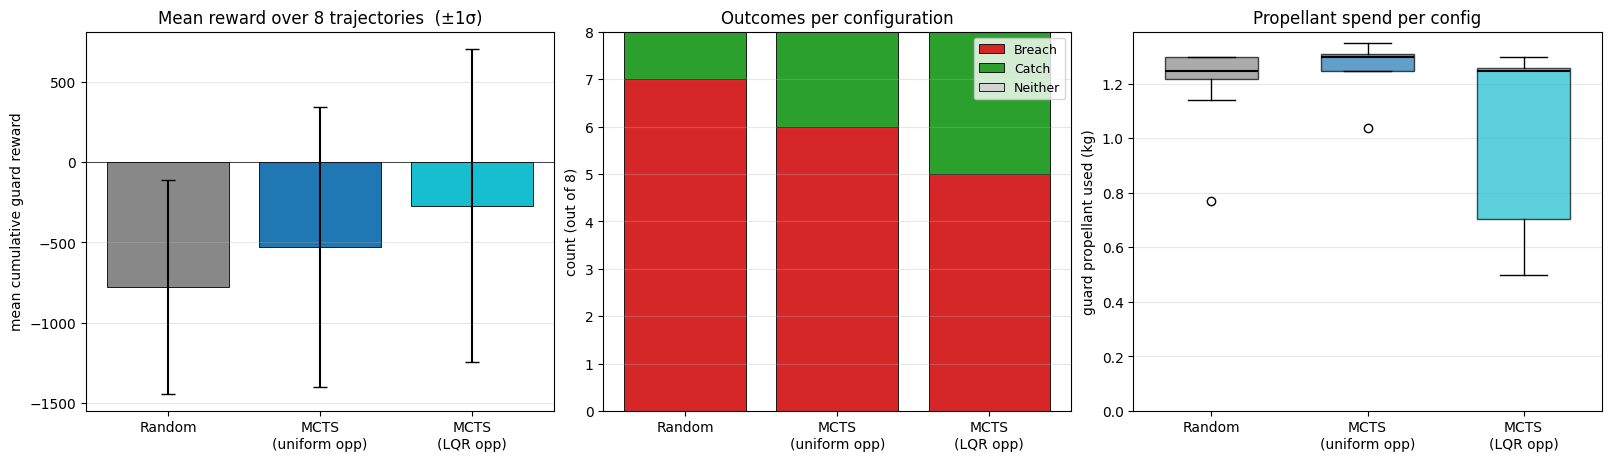

In [14]:
names = [n for n, _, _ in configs]
colors = [c for _, _, c in configs]
mean_r = np.array([results[n][0].mean() for n in names])
std_r = np.array([results[n][0].std() for n in names])
breach_counts = np.array([results[n][2] for n in names])
catch_counts = np.array([results[n][3] for n in names])
neither_counts = N_TRAJ - breach_counts - catch_counts
prop_arrays = [results[n][1] for n in names]

fig, axes = plt.subplots(1, 3, figsize=(16, 4.5), constrained_layout=True)

# (a) Mean cumulative guard reward, with ±1 σ error bars.
ax = axes[0]
ax.bar(names, mean_r, yerr=std_r, color=colors, edgecolor='black',
       linewidth=0.6, capsize=5)
ax.axhline(0, color='k', linewidth=0.5)
ax.set_ylabel('mean cumulative guard reward')
ax.set_title(f'Mean reward over {N_TRAJ} trajectories  (±1σ)')
ax.grid(axis='y', alpha=0.3)

# (b) Outcome stack: breaches + catches + neither.
ax = axes[1]
x = np.arange(len(names))
ax.bar(x, breach_counts, color='tab:red', edgecolor='black', linewidth=0.6, label='Breach')
ax.bar(x, catch_counts, bottom=breach_counts,
       color='tab:green', edgecolor='black', linewidth=0.6, label='Catch')
ax.bar(x, neither_counts, bottom=breach_counts + catch_counts,
       color='lightgray', edgecolor='black', linewidth=0.6, label='Neither')
ax.set_xticks(x); ax.set_xticklabels(names)
ax.set_ylabel(f'count (out of {N_TRAJ})')
ax.set_ylim(0, N_TRAJ)
ax.set_title('Outcomes per configuration')
ax.legend(loc='best', fontsize=9)
ax.grid(axis='y', alpha=0.3)

# (c) Propellant-used distribution per config.
ax = axes[2]
bp = ax.boxplot(prop_arrays, labels=names, patch_artist=True, widths=0.6,
                medianprops=dict(color='black', linewidth=1.5))
for patch, c in zip(bp['boxes'], colors):
    patch.set_facecolor(c)
    patch.set_alpha(0.7)
ax.set_ylabel('guard propellant used (kg)')
ax.set_title('Propellant spend per config')
ax.grid(axis='y', alpha=0.3)
ax.set_ylim(bottom=0)

plt.show()


## 11. Notes

- `MCTSPolicy` is symmetric — wire it for guard or bandit, with any
  `opponent_model`. The same machinery plays either side.
- For `MCTSPolicy` + KF/EKF beliefs, write a Belief whose `mean`
  field is the adapter's flat state vector and drive via
  `belief_rollout`. See `docs/in-depth/mcts.md`.
- Increasing `num_simulations` widens the tree but linearly increases
  per-step cost. The Δv-budget plot above is a good sanity check that
  more search isn't just burning more fuel.